<center>Universidade Federal de Viçosa</center>
<center>Coordenadoria de Educação Aberta e a Distância</center>
<center>Inteligência Artificial e Computacional</center>
<center>ELT578 - Análise de Imagens e Visão Computacional</center>

**<center>AULA PRÁTICA 7: Descritores de Objeto</center>**

In [1]:
#Permissão para acessar o drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Importando bibliotecas
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from skimage.io import imread, imshow
from scipy import stats
from matplotlib import pyplot as plt

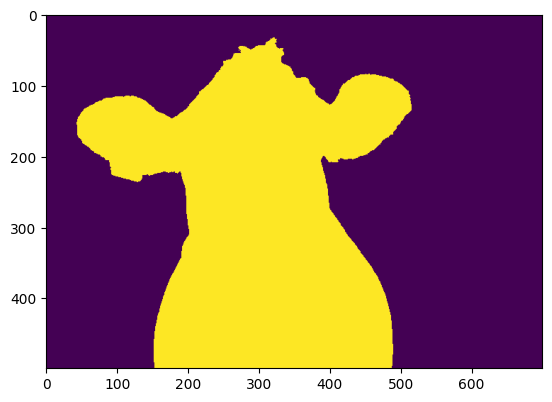

In [3]:
binaryImage = imread(r'/content/drive/MyDrive/ELT578/SEMANA_3/cowbw.png')
Segim = plt.imshow(binaryImage)

In [4]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import plotly.graph_objects as go
from skimage import data, filters, measure, morphology
from skimage.measure import label, regionprops_table

labels = label(binaryImage)
props = regionprops_table(labels, properties=('centroid','perimeter','area','orientation','eccentricity','solidity', 'major_axis_length', 'minor_axis_length'))
pd.DataFrame(props)

#Orientação: refere-se ao ângulo no qual um objeto ou forma é orientado dentro de uma imagem.
#Excentricidade: A excentricidade é uma medida de quanto uma elipse (ou objeto) se desvia de ser perfeitamente circular. É um valor adimensional entre 0 e 1, onde 0 representa um círculo perfeito e valores mais altos indicam maior alongamento.
#Solidez: é uma medida de quão convexa ou côncava é uma forma. É a razão entre a área do objeto e a área de seu casco convexo. O casco convexo é a menor forma convexa que envolve o objeto.
#Area e perimetro: A área mede a extensão de uma superfície, enquanto o perímetro mede o comprimento do contorno de uma forma. A área é medida em unidades quadradas, enquanto o perímetro é medido em unidades lineares.

,centroid-0,centroid-1,perimeter,area,orientation,eccentricity,solidity,major_axis_length,minor_axis_length
0,283.665777,302.04253,2114.634739,128474.0,0.242086,0.64139,0.725375,517.373119,396.93629
1,51.000000,272.00000,0.000000,1.0,-0.785398,0.00000,1.000000,0.000000,0.00000


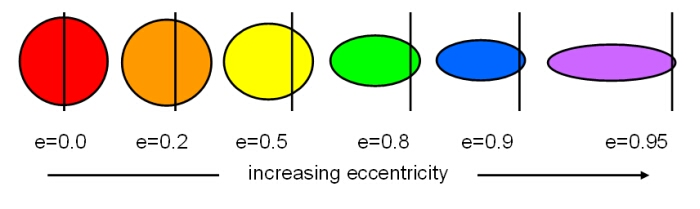


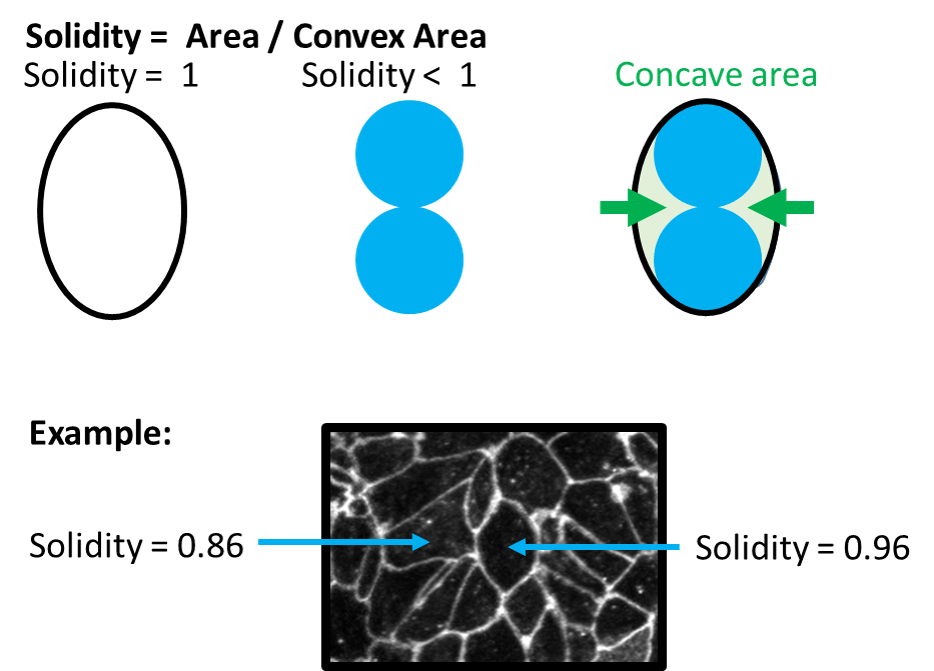


In [7]:
binaryImage = imread(r'/content/drive/MyDrive/ELT578/SEMANA_3/cowbw2.jpg')

ret,thresh = cv2.threshold(binaryImage,127,255,0)
contours, hierarchy = cv2.findContours(thresh,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
cnt = contours[0]

area = cv2.contourArea(cnt) #Area

perimeter = cv2.arcLength(cnt,True) #Perimetro

FF = (4*np.pi*area)/(np.power(perimeter,2)) #Fator de Forma

compacidade = (np.power(perimeter,2))/area #Compacidade

rect = cv2.minAreaRect(cnt) #Excentricidade (Retângulo envolvente)
E_maior = max(rect[1])
E_menor = min(rect[1])
Excentricidade = E_maior/E_menor

Retangularidade = area/(E_maior*E_menor) #Retangularidade

Fecho = cv2.convexHull(cnt) #Convexidade (Contorno convexo)
Fecho = Fecho.astype(int)
Convexidade = len(Fecho)/perimeter

area = cv2.contourArea(cnt) #Solidez
hull = cv2.convexHull(cnt)
hull_area = cv2.contourArea(hull)
solidity = float(area)/hull_area

print(area)
print(perimeter)
print(FF)
print(compacidade)
print(Excentricidade)
print(Retangularidade)
print(Convexidade)
print(solidity)

127416.5
2149.800199866295
0.346449020219499
36.271918466958056
1.0150214592274678
0.5780675806876027
0.010233509142555794
0.7219678726237357
